# prepare log sample

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
log_sample = pd.read_csv("Desktop/sample_log.csv")
log_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Timestamp        14400 non-null  object
 1   Client_ID        14400 non-null  object
 2   Executable_name  14400 non-null  object
 3   Win_title        14400 non-null  object
 4   Status           14400 non-null  object
dtypes: object(5)
memory usage: 562.6+ KB


In [3]:
log_sample.head()

,Timestamp,Client_ID,Executable_name,Win_title,Status
0,2026-07-12 09:00:00,TABLET-C2946UOC,vscode.exe,Project_Folder - main.py,active
1,2026-07-12 09:00:02,TABLET-C2946UOC,chrome.exe,Google Search,active
2,2026-07-12 09:00:04,TABLET-C2946UOC,slack.exe,Direct Messages,active
3,2026-07-12 09:00:06,TABLET-C2946UOC,vscode.exe,Project_Folder - main.py,active
4,2026-07-12 09:00:08,TABLET-C2946UOC,vscode.exe,settings.json,active


# functionality 1: top 3 used apps

In [6]:
app_count = log_sample.groupby(
    by = "Executable_name", as_index=False)["Status"].agg("count")

In [7]:
app_count = app_count.sort_values("Status", ascending=False, ignore_index=True)

In [8]:
app_count

,Executable_name,Status
0,excel.exe,2959
1,slack.exe,2935
2,chrome.exe,2848
3,vscode.exe,2846
4,spotify.exe,2812


In [9]:
for i in range(3):
    print(f"the top {i+1} app you used is {app_count.iloc[i,0]}.")

the top 1 app you used is excel.exe.
the top 2 app you used is slack.exe.
the top 3 app you used is chrome.exe.


# functionality 2: visualize the time

In [10]:
log_bar = log_sample

In [11]:
log_bar['Timestamp'] = pd.to_datetime(log_bar['Timestamp'])

In [12]:
log_bar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Timestamp         14400 non-null  datetime64[ns]
 1   Client_ID         14400 non-null  object        
 2   Executable_name   14400 non-null  object        
 3   Win_title         14400 non-null  object        
 4   Status            14400 non-null  object        
 5   duration_seconds  14400 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 675.1+ KB


In [13]:
log_bar["Timestamp"] = log_bar["Timestamp"].dt.strftime("%m-%d")

In [14]:
log_bar["Duration_seconds"] = 2

In [15]:
log_bar.head()

,Timestamp,Client_ID,Executable_name,Win_title,Status,duration_seconds,Duration_seconds
0,07-12,TABLET-C2946UOC,vscode.exe,Project_Folder - main.py,active,2,2
1,07-12,TABLET-C2946UOC,chrome.exe,Google Search,active,2,2
2,07-12,TABLET-C2946UOC,slack.exe,Direct Messages,active,2,2
3,07-12,TABLET-C2946UOC,vscode.exe,Project_Folder - main.py,active,2,2
4,07-12,TABLET-C2946UOC,vscode.exe,settings.json,active,2,2


In [16]:
total_time = log_bar.groupby(["Timestamp", "Executable_name"], as_index=False)["Duration_seconds"].agg("sum")

In [17]:
total_time = total_time.sort_values("Duration_seconds", ascending=False, ignore_index=True)

In [18]:
total_time

,Timestamp,Executable_name,Duration_seconds
0,07-12,excel.exe,5918
1,07-12,slack.exe,5870
2,07-12,chrome.exe,5696
3,07-12,vscode.exe,5692
4,07-12,spotify.exe,5624


In [19]:
total_time["Duration_minutes"] = total_time["Duration_seconds"] / 60

In [20]:
total_time["Duration_hours"] = total_time["Duration_minutes"] / 60

In [21]:
total_time["Actual_hours"] = np.floor(total_time["Duration_hours"]).astype("int")

In [22]:
total_time["Acutal_minutes"] = (total_time["Duration_hours"] - total_time["Actual_hours"]) * 60

In [23]:
total_time["Acutal_minutes"] = total_time["Acutal_minutes"].apply(round)

In [24]:
#total_time["Time_label"] = total_time["Duration_hours"].str.format("f{.00}")
total_time["Time_label"] = total_time["Duration_hours"].map("{:.2f} Hour(s)".format)

In [25]:
total_time

,Timestamp,Executable_name,Duration_seconds,Duration_minutes,Duration_hours,Actual_hours,Acutal_minutes,Time_label
0,07-12,excel.exe,5918,98.633333,1.643889,1,39,1.64 Hour(s)
1,07-12,slack.exe,5870,97.833333,1.630556,1,38,1.63 Hour(s)
2,07-12,chrome.exe,5696,94.933333,1.582222,1,35,1.58 Hour(s)
3,07-12,vscode.exe,5692,94.866667,1.581111,1,35,1.58 Hour(s)
4,07-12,spotify.exe,5624,93.733333,1.562222,1,34,1.56 Hour(s)


<Axes: xlabel='Timestamp', ylabel='Count'>

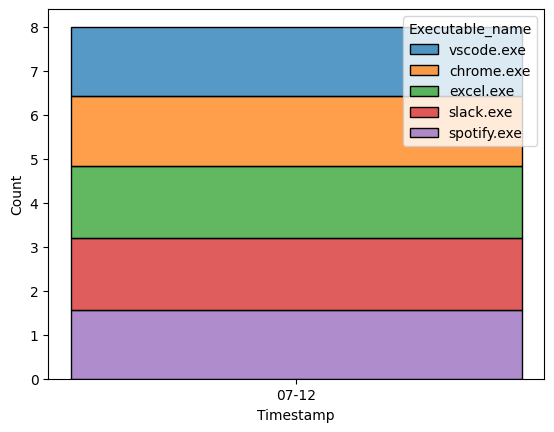

In [26]:
# Optional: stack them in a specific order
sns.histplot(
    data=total_time, 
    x="Timestamp", 
    weights="Duration_hours", 
    hue="Executable_name", 
    multiple="stack",
    hue_order=['vscode.exe', 'chrome.exe', 'excel.exe', 'slack.exe', 'spotify.exe'] 
)

# functionality 3: a brief AI summary

In [39]:
import google.generativeai as genai
import tabulate

In [ ]:
genai.configure(api_key="GEMINIAPIKEY")
model = genai.GenerativeModel('gemini-flash-lite-latest')

In [52]:
table_as_text = work_details.to_markdown(index=False)

In [53]:
table_as_text

'| Executable_name   | Win_title                |   duration_seconds |\n|:------------------|:-------------------------|-------------------:|\n| chrome.exe        | GitHub - Pull Requests   |               1896 |\n| chrome.exe        | Google Search            |               1946 |\n| chrome.exe        | YouTube                  |               1854 |\n| excel.exe         | Budget_Report.xlsx       |               2992 |\n| excel.exe         | Sales_Data.csv           |               2926 |\n| slack.exe         | Direct Messages          |               3008 |\n| slack.exe         | General Channel          |               2862 |\n| spotify.exe       | Chill Beats              |               2754 |\n| spotify.exe       | Focus Playlist           |               2870 |\n| vscode.exe        | Project_Folder - main.py |               2790 |\n| vscode.exe        | settings.json            |               2902 |'

In [27]:
work_content = log_sample
work_content["duration_seconds"] = 2

In [28]:
work_details = work_content.groupby(["Executable_name", "Win_title"], as_index=False)["duration_seconds"].agg("sum")

In [30]:
work_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Executable_name   11 non-null     object
 1   Win_title         11 non-null     object
 2   duration_seconds  11 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 396.0+ bytes


In [31]:
work_details.head()

,Executable_name,Win_title,duration_seconds
0,chrome.exe,GitHub - Pull Requests,1896
1,chrome.exe,Google Search,1946
2,chrome.exe,YouTube,1854
3,excel.exe,Budget_Report.xlsx,2992
4,excel.exe,Sales_Data.csv,2926


In [61]:
prompt = f"""
以下のPC作業ログに基づいて、今日の主要な作業内容を最大3点にまとめてください。
duration_secondsの数値を参考に、最も時間をかけている作業を優先して要約対象に選定してください。

【形式】
作業内容1：[要約]
作業内容2：[要約]
作業内容3：[要約]

【制約事項】
- 作業時間や秒数は出力に含めないこと。
- 「以下は回答です」などの前置き、挨拶、結びの言葉は一切不要。
- 箇条書きのみを出力すること。余計な説明は禁止。
- 必ず3点以内でまとめること。

【データ】
{table_as_text}
"""

In [62]:
response = model.generate_content(prompt)
print(response.text)

作業内容1：Slackを用いたチームメンバーとのコミュニケーションおよびチャット対応
作業内容2：Excelを使用した予算レポートの作成および売上データの集計
作業内容3：VS Codeによるプログラムのコーディングおよび開発環境の設定変更


In [46]:
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(f"Model name: {m.name}")

Model name: models/gemini-2.5-flash
Model name: models/gemini-2.5-pro
Model name: models/gemini-2.0-flash
Model name: models/gemini-2.0-flash-001
Model name: models/gemini-2.0-flash-lite-001
Model name: models/gemini-2.0-flash-lite
Model name: models/gemini-2.5-flash-preview-tts
Model name: models/gemini-2.5-pro-preview-tts
Model name: models/gemma-4-26b-a4b-it
Model name: models/gemma-4-31b-it
Model name: models/gemini-flash-latest
Model name: models/gemini-flash-lite-latest
Model name: models/gemini-pro-latest
Model name: models/gemini-2.5-flash-lite
Model name: models/gemini-2.5-flash-image
Model name: models/gemini-3-pro-preview
Model name: models/gemini-3-flash-preview
Model name: models/gemini-3.1-pro-preview
Model name: models/gemini-3.1-pro-preview-customtools
Model name: models/gemini-3.1-flash-lite-preview
Model name: models/gemini-3.1-flash-lite
Model name: models/gemini-3-pro-image-preview
Model name: models/gemini-3-pro-image
Model name: models/nano-banana-pro-preview
Mode